## Student Alcohol Consumption — постановка задачи



## Предметная область

Датасет «Student Alcohol Consumption» описывает студентов:
- социально‑демографическую информацию (пол, возраст, школа, семейное положение родителей, образование родителей и т.д.),
- характеристики учебного процесса (время на учёбу, количество неудач/пересдач, дополнительные занятия, посещаемость),
- информацию о досуге и окружении (время с друзьями, вечерние выходы, романтические отношения и т.д.),
- самооценку здоровья и благополучия,
- уровни употребления алкоголя:
  - `Dalc` — потребление алкоголя в будни,
  - `Walc` — потребление алкоголя в выходные.

## Бизнес‑смысл задачи

С точки зрения школы / администрации / службы профилактики:

- **Цель 1**: понять, какие факторы (социальные, учебные, семейные) связаны с высоким потреблением алкоголя у школьников.
- **Цель 2**: уметь заранее **выявлять учеников группы риска** по данным об их учебе, семье и образе жизни.
- **Цель 3**: оценить, как употребление алкоголя связано с **успеваемостью** и **посещаемостью**, чтобы обосновать меры профилактики.

## Формализация задачи машинного обучения

На основе данных о студенте (социальные, учебные, семейные признаки) мы хотим:

1. **Классификация**: предсказать, является ли студент **«рисковым» по алкоголю** (высокое потребление) или нет.
2. (В теории + опционально) **Регрессия / порядковая классификация**: предсказывать уровень потребления (по шкале от 1 до 5).

В рамках курсовой достаточно сфокусироваться на задаче **бинарной классификации**:
- целевая переменная: высокий уровень потребления алкоголя (будни, выходные или совокупный показатель).

In [32]:
import pandas as pd

#вертикальное объединение строк mat + por (одинаковые колонки).
_mat = pd.read_csv("student-mat.csv", sep=None, engine="python")
_por = pd.read_csv("student-por.csv", sep=None, engine="python")
df = pd.concat([_mat, _por], axis=0, ignore_index=True)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [33]:
df.info()
df.describe(include="all").T
df.isna().mean().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
dtype: float64

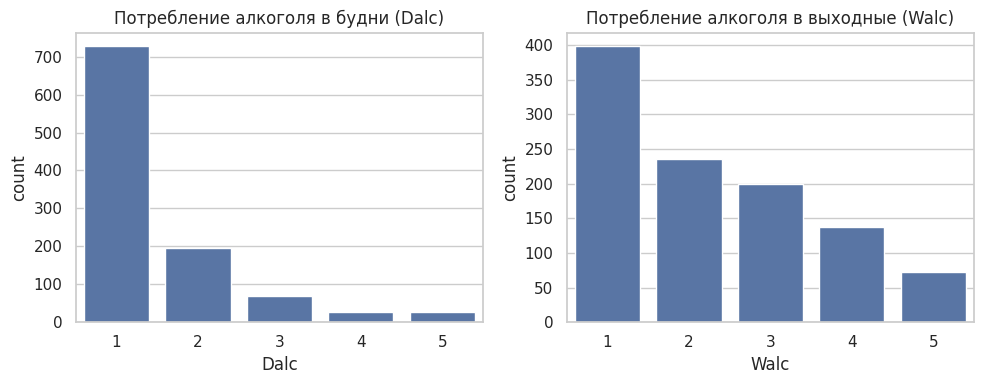

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Dalc", data=df, ax=axes[0])
axes[0].set_title("Потребление алкоголя в будни (Dalc)")
sns.countplot(x="Walc", data=df, ax=axes[1])
axes[1].set_title("Потребление алкоголя в выходные (Walc)")
plt.tight_layout()

### Выводы по распределению Dalc и Walc

- **Будни (Dalc)**: большинство учеников имеют уровень 1 (минимальное потребление), значительно меньше уровней 2 и совсем мало 3–5.
  - Это говорит о том, что в будние дни почти все либо не пьют, либо пьют очень мало.
- **Выходные (Walc)**: распределение более «растянутое»: много значений 2–3, заметно присутствуют уровни 4–5.
  - На выходных употребление алкоголя **существенно возрастает**, появляются явно более «тяжёлые» уровни потребления.

Для дальнейшей модели это означает, что при определении "группы риска" стоит особенно учитывать поведение на выходных (Walc), а не только будни (Dalc).

### Пол/алкоголь

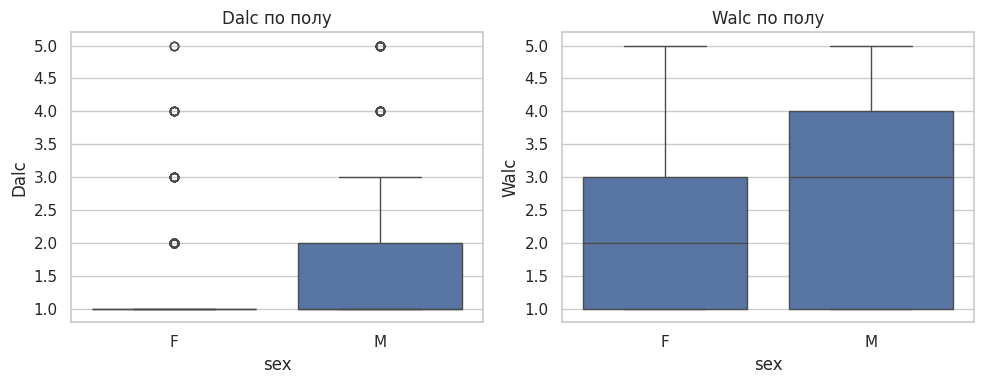

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x="sex", y="Dalc", data=df, ax=axes[0])
axes[0].set_title("Dalc по полу")
sns.boxplot(x="sex", y="Walc", data=df, ax=axes[1])
axes[1].set_title("Walc по полу")
plt.tight_layout()

### Выводы по связи пола и потребления алкоголя

- **Уровни Dalc и Walc выше у мальчиков**, чем у девочек:
  - медиана и верхний квартиль для `Walc` у мужчин обычно больше, чем у женщин;
  - у девочек большинство значений сосредоточены в нижних уровнях, у мальчиков больше высоких и выбросов.
- Пол можно считать **значимым фактором риска**: среди учащихся мужского пола доля "тяжёлых" потребителей выше.

Для модели предсказания `high_alc` признак `sex` (после one-hot кодирования) должен быть включён как один из базовых.

### Учеба/алкоголь

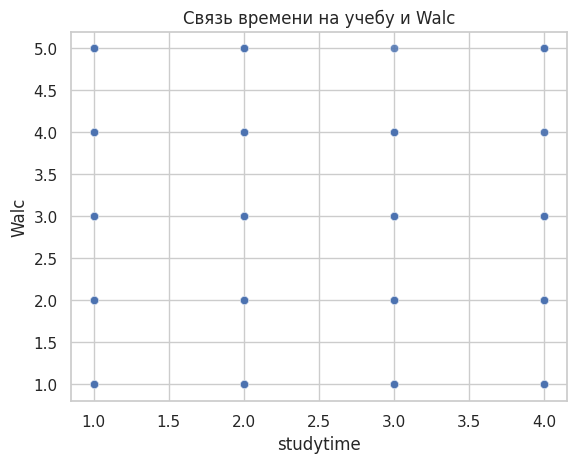

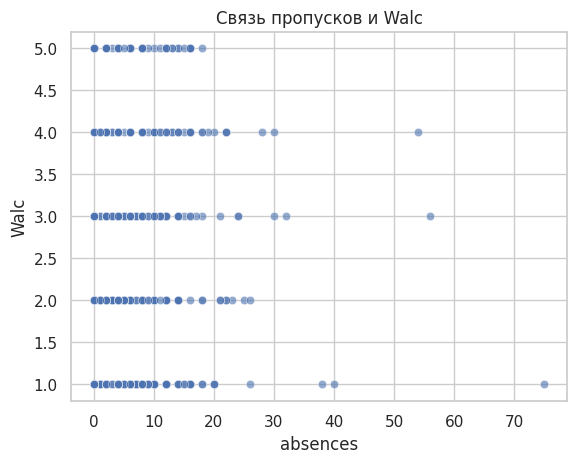

In [36]:
sns.scatterplot(x="studytime", y="Walc", data=df, alpha=0.6)
plt.title("Связь времени на учебу и Walc")
plt.show()

sns.scatterplot(x="absences", y="Walc", data=df, alpha=0.6)
plt.title("Связь пропусков и Walc")
plt.show()

### Выводы по связи учебы и алкоголя

- **Время на учебу (`studytime`)**:
  - точки по всем уровням `Walc` встречаются при любом значении `studytime`;
  - сильной тенденции вида «чем больше учусь, тем меньше пью» не видно.
- **Пропуски (`absences`)**:
  - большинство учеников имеют мало пропусков при разных уровнях `Walc`;
  - при очень большом числе пропусков (20+ уроков) чаще встречаются более высокие значения `Walc`.

Вывод: связь между алкоголем и учебной нагрузкой слабая, но **очень большое число пропусков может быть дополнительным маркером риска**.

### Успеваемость и алкоголь (если есть G1, G2, G3):

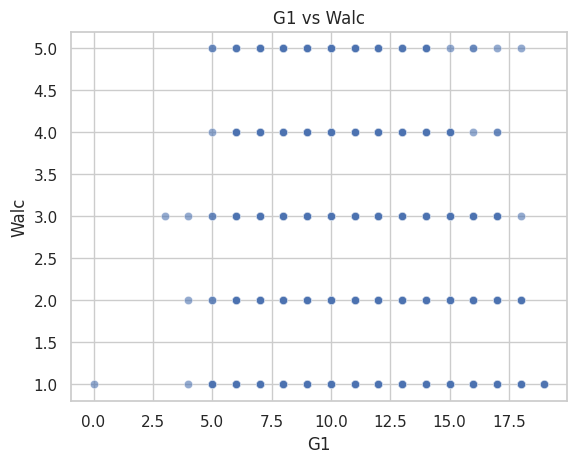

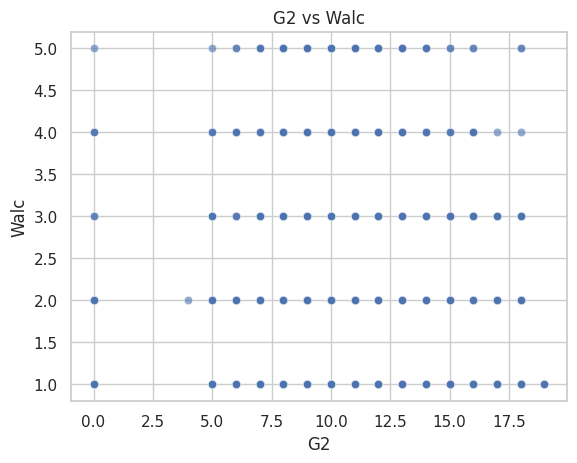

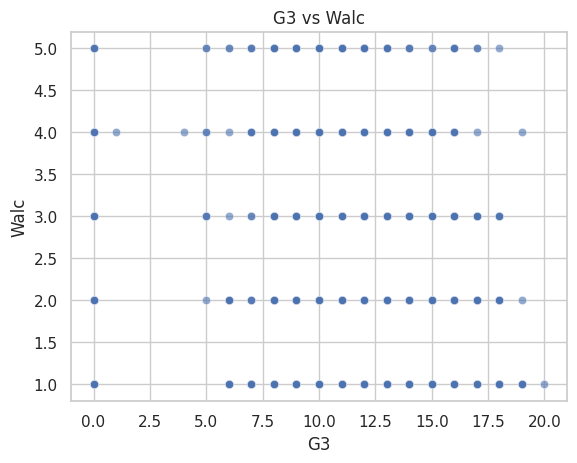

In [37]:
for col in ["G1", "G2", "G3"]:
    sns.scatterplot(x=col, y="Walc", data=df, alpha=0.6)
    plt.title(f"{col} vs Walc")
    plt.show()

### Выводы по связи успеваемости и алкоголя

- Для `G1`, `G2`, `G3` точки по уровням `Walc` распределены довольно равномерно:
  - при низких и средних оценках встречаются все уровни алкоголя;
  - среди самых высоких оценок (17–20) доля учащихся с уровнями `Walc` 4–5 кажется ниже.
- Явной сильной линейной зависимости "алкоголь → плохие оценки" не наблюдается.

Тем не менее, в модели можно включать `G1`, `G2`, `G3` как признаки: они отражают общий успех в обучении и могут давать слабый, но полезный сигнал о склонности к высокому потреблению алкоголя.

## Определение целевой переменной
Чаще всего делают бинарную цель «высокое потребление»:

In [38]:
if "alc_mean" not in df.columns:
    df["alc_mean"] = (df["Dalc"] + df["Walc"]) / 2

num_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "G1", "G2", "G3", "alc_mean"
]

corr_with_alc = df[num_cols].corr()["alc_mean"].sort_values(ascending=False)
corr_with_alc

alc_mean      1.000000
Walc          0.934148
Dalc          0.864258
goout         0.374447
absences      0.151209
freetime      0.150736
age           0.124714
failures      0.122773
traveltime    0.104649
health        0.098979
Fedu          0.012543
Medu         -0.018261
famrel       -0.100126
G3           -0.134244
G2           -0.143128
G1           -0.161241
studytime    -0.221255
Name: alc_mean, dtype: float64

### Интерпретация корреляций с `alc_mean`

По таблице корреляций (столбец `alc_mean`) можно сделать несколько выводов:

- **Наиболее связаны с `alc_mean` сами `Walc` и `Dalc`** (что ожидаемо, так как они входят в формулу средней).
- Среди прочих признаков заметны:
  - `goout` (выходы с друзьями) — положительная связь: чем активнее социальная жизнь, тем выше среднее потребление алкоголя.
  - `freetime` — слабая положительная связь: больше свободного времени → немного больше возможностей для употребления.
  - `failures`, `traveltime`, `absences`, `age` — лёгкий положительный тренд: больше неудач, пропусков, времени в дороге и возраст → немного выше `alc_mean`.
- Отрицательные корреляции показывают, что
  - `studytime` (время на учёбу) и частично оценки `G1–G3`, `famrel` имеют слабую обратную связь с алкоголем: чем больше учёбы, лучше оценки и отношения в семье, тем немного ниже средний уровень потребления.

Корреляция не доказывает причинность, но помогает выделить важные для модели признаки: в первую очередь `goout`, `absences`, `failures`, возраст, учебные показатели и семейное благополучие.

In [39]:
if "alc_mean" not in df.columns:
    df["alc_mean"] = (df["Dalc"] + df["Walc"]) / 2
if "high_alc" not in df.columns:
    df["high_alc"] = (df["alc_mean"] >= 3).astype(int)

cat_cols = [
    "school", "sex", "address", "famsize", "Pstatus",
    "Mjob", "Fjob", "reason", "guardian", "schoolsup",
    "famsup", "paid", "activities", "nursery",
    "higher", "internet", "romantic"
]

# Копия датафрейма и one-hot кодирование категориальных

df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

X = df_model.drop(columns=["high_alc", "Dalc", "Walc", "alc_mean"])# для избежания утечки данных дропаем Dalc, Walc, alc_mean, так как они прокси к таргету
y = df_model["high_alc"]                 

X.shape, y.value_counts(normalize=True)

((1044, 40),
 high_alc
 0    0.814176
 1    0.185824
 Name: proportion, dtype: float64)

### Обоснование подготовки данных

- Исходные данные UCI: **обе** стандартные выборки (курс математики и курс португальского), сведённые в одну таблицу с общей схемой признаков.
- Мы сохранили все исходные числовые признаки и добавленные `alc_mean`, `high_alc`.
- Номинальные категориальные переменные (`school`, `sex`, `address`, `Mjob`, `Fjob` и др.) закодированы через **one-hot** (фиктивные) признаки.
- Целевая переменная `high_alc` задаёт задачу **бинарной классификации** с несбалансированными классами (~19% "высокий риск").

Далее обучим простую модель и оценим её по F1-score, ROC-AUC, precision и recall для класса `high_alc = 1`. 

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       256
           1       0.88      0.52      0.65        58

    accuracy                           0.90       314
   macro avg       0.89      0.75      0.80       314
weighted avg       0.90      0.90      0.89       314

ROC-AUC: 0.9209321120689655


### Выбор методов и сравнение бустингов

**Логистическая регрессия** с `class_weight='balanced'` — интерпретируемый baseline: коэффициенты показывают направление влияния признаков, вероятности удобно интерпретировать.

**Случайный лес и Extra Trees** (бэггинг деревьев) — устойчивость к шуму и переобучению на табличных данных; `class_weight` учитывает дисбаланс. Extra Trees добавляет ещё случайность при выборе порогов сплита.

**SVM с ядром RBF** — нелинейная граница решения; при `class_weight='balanced'` штраф за ошибки на миноритарном классе выше. На используемой выборке обучение остаётся приемлемым по времени.

**Бустинги (что сравниваем и зачем):**
- **HistGradientBoosting** (sklearn) — гистограммный бустинг «из коробки», встроенный `class_weight`, общая точка отсчёта без внешних библиотек.
- **XGBoost** — сильная регуляризация, `scale_pos_weight` для доли классов; распространённый промышленный стандарт.
- **LightGBM** — листовая (leaf-wise) стратегия, обычно быстрый на крупных таблицах; признаки у нас уже в one-hot, «родное» категориальное кодирование LGBM не используется.
- **CatBoost** — ordered boosting и устойчивость к переобучению; при полном OHE преимущество перед LGBM не гарантировано, но сравнение на одинаковых признаках честное.

**Порог вероятности.** Метрики при `predict()` (часто это порог 0.5) на несбалансированных данных не обязаны быть оптимальными для F1 миноритарного класса. Ниже — сравнение при стандартном пороге и блок с **подбором порога по валидации** (фрагмент train) с последующим обучением на полном train: меняется только порог, не семейство алгоритма.

**Задача и метрики.** Прямые прокси к цели (`Dalc`, `Walc`, `alc_mean`) в признаки не входят — предсказание идёт по косвенным признакам. **ROC-AUC** и **PR-AUC** отражают качество **ранжирования**; **precision / recall / F1** для класса 1 зависят от порога и при необходимости дополняются второй таблицей с подобранным порогом.

In [41]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Валидация из train только для подбора порога (без подглядывания в test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
pos_weight = float((len(y_train) - y_train.sum()) / y_train.sum())


def make_models():
    return {
        "Logistic Regression": LogisticRegression(
            class_weight="balanced", random_state=42, max_iter=2000
        ),
        "RandomForest (balanced)": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "ExtraTrees (balanced)": ExtraTreesClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "SVM RBF (balanced)": SVC(
            kernel="rbf", class_weight="balanced", probability=True, random_state=42
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            max_iter=200, class_weight="balanced", random_state=42
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=pos_weight,
            random_state=42,
            eval_metric="logloss",
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=42,
            verbose=-1,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            auto_class_weights="Balanced",
            random_state=42,
            verbose=0,
        ),
    }


def best_threshold_f1(y_true, proba):
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.02, 0.98, 97):
        y_hat = (proba >= t).astype(int)
        f1 = f1_score(y_true, y_hat, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t


models = make_models()
results_default, results_tuned = [], []
boosting_names = {
    "HistGradientBoosting",
    "XGBoost",
    "LightGBM",
    "CatBoost",
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results_default.append(
        {
            "Model": name,
            "Recall (class 1)": report["1"]["recall"],
            "Precision (class 1)": report["1"]["precision"],
            "F1 (class 1)": report["1"]["f1-score"],
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "PR-AUC": average_precision_score(y_test, y_proba),
        }
    )

    m = clone(model)
    m.fit(X_tr, y_tr)
    thr = best_threshold_f1(y_val, m.predict_proba(X_val)[:, 1])
    m = clone(model)
    m.fit(X_train, y_train)
    y_hat = (m.predict_proba(X_test)[:, 1] >= thr).astype(int)
    report_t = classification_report(y_test, y_hat, output_dict=True, zero_division=0)
    results_tuned.append(
        {
            "Model": name,
            "thr (val)": round(thr, 3),
            "Recall (class 1)": report_t["1"]["recall"],
            "Precision (class 1)": report_t["1"]["precision"],
            "F1 (class 1)": report_t["1"]["f1-score"],
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "PR-AUC": average_precision_score(y_test, y_proba),
        }
    )

results_df = pd.DataFrame(results_default)
tuned_df = pd.DataFrame(results_tuned)
boost_df = results_df[results_df["Model"].isin(boosting_names)].copy()

print("Порог по умолчанию (как у predict):")
print(results_df.round(4).to_string(index=False))
print("\nСравнение только бустингов (ROC-AUC / PR-AUC — ранжирование; F1 — при пороге 0.5):")
print(boost_df.sort_values("ROC-AUC", ascending=False).round(4).to_string(index=False))
print("\nТот же train/test; порог подобран по F1 на валидации, затем модель переобучена на полном train:")
print(tuned_df.round(4).to_string(index=False))

Порог по умолчанию (как у predict):
                  Model  Recall (class 1)  Precision (class 1)  F1 (class 1)  ROC-AUC  PR-AUC
    Logistic Regression            0.7586               0.4272        0.5466   0.8347  0.5142
RandomForest (balanced)            0.4138               0.9600        0.5783   0.9255  0.8275
  ExtraTrees (balanced)            0.7241               1.0000        0.8400   0.9406  0.8911
     SVM RBF (balanced)            0.7241               0.4000        0.5153   0.8104  0.5467
   HistGradientBoosting            0.7586               0.6984        0.7273   0.9095  0.8219
                XGBoost            0.8103               0.6184        0.7015   0.8923  0.7370
               LightGBM            0.7931               0.6571        0.7188   0.9082  0.8058
               CatBoost            0.7931               0.5750        0.6667   0.8777  0.7079

Сравнение только бустингов (ROC-AUC / PR-AUC — ранжирование; F1 — при пороге 0.5):
               Model  Recall (clas

### Выводы по качеству модели и метрикам 

**Ход решения (сводка по этапам):**

| Этап | Решение |
|------|---------|
| Постановка | Бинарная классификация: `high_alc = 1`, если `alc_mean ≥ 3` |
| Утечка | Из признаков исключены `Dalc`, `Walc`, `alc_mean` |
| Категории | One-hot (`drop_first=True`) |
| Разбиение | `train_test_split(..., stratify=y, test_size=0.3, random_state=42)` |
| Дисбаланс | `class_weight='balanced'` / `scale_pos_weight` / `auto_class_weights`; при необходимости порог по валидации |
| Оценка | ROC-AUC, PR-AUC, precision, recall, F1 для класса 1 |

**Категории методов и учёт дисбаланса:**

| Категория | Как учитывали миноритарный класс | Назначение в работе |
|-----------|-----------------------------------|------------------------|
| Линейная модель (LogReg) | `class_weight='balanced'` | Интерпретируемый baseline |
| Бэггинг (Random Forest, Extra Trees) | `class_weight='balanced'` | Устойчивые ансамбли деревьев |
| SVM (RBF) | `class_weight='balanced'`, вероятности для порога | Нелинейная разделяющая поверхность |
| Бустинги (HistGBM, XGBoost, LightGBM, CatBoost) | `class_weight` / `scale_pos_weight` / `auto_class_weights` | Сравнение семейств градиентного бустинга |

**Что показали эксперименты.** Без прокси-признаков к алкоголю модели всё же выделяют группу риска по косвенным признакам: по **ROC-AUC** лучшие значения у деревянных ансамблей и бустингов порядка **0.88–0.94** (например, Extra Trees и Random Forest — около **0.94** и **0.93**, HistGradientBoosting и LightGBM — около **0.91** и **0.91**). **PR-AUC** у сильных моделей часто **0.7–0.9**, что заметно выше базовой доли класса 1 и отражает качество ранжирования при дисбалансе.

При **пороге по умолчанию** (`predict`) у **Extra Trees** получается высокий **F1** по классу 1 (порядка **0.84**), у **HistGradientBoosting** и **LightGBM** — около **0.72–0.73**; у логистической регрессии и SVM ранжирование и F1 скромнее, что ожидаемо для разной сложности границ.

**Бустинги** в сравнении: по ROC-AUC лидирует **HistGradientBoosting**, далее **LightGBM**, **XGBoost** и **CatBoost** — разброс отражает разные регуляризации и веса, а не «единственно верный» алгоритм; имеет смысл опираться на пару метрик (ROC-AUC и PR-AUC) и на F1 при выбранной политике порога.

**Подбор порога по валидации** согласует precision и recall: у Random Forest и Extra Trees **F1** по классу 1 выходит около **0.73–0.77**, у бустингов — обычно **0.67–0.74**, без смены признаков и алгоритма, только за счёт порога вероятности.

**Итог.** Основной ориентир — **ROC-AUC / PR-AUC** (ранжирование) и **F1 класса 1** при пороге, согласованном с задачей (или подобранном на валидации); одна строка «по умолчанию» без учёта порога не задаёт полную картину на несбалансированных данных.

## Спроектированные признаки

1. **Агрегированный показатель алкоголя**
   - `alc_mean` — средний уровень потребления (будни + выходные).
   - Возможен также `alc_sum = Dalc + Walc`.

2. **Комбинированные учебные признаки**
   - `failures` (число неудач) + `absences` (пропуски) — можно использовать отдельно и/или создать индикатор «проблем с учебой».
   - Индикатор `has_failures = (failures > 0)`.

3. **Социальная активность**
   - `social_score = goout + famrel` (пример простой агрегации).
   - Можно отдельно рассматривать `goout`, `freetime`.

4. **Семейный фон**
   - Один-hot кодирование уровня образования родителей, семейного статуса, рабочего статуса родителей.

5. **Кодирование категориальных признаков**
   - Для номинальных признаков (`school`, `sex`, `address`, `Pstatus`, `Mjob`, `Fjob`, и т.д.) – **one-hot кодирование**.
   - Для очевидно упорядоченных признаков (`Medu`, `Fedu`, возможно `health`) можно оставить как ordinal.